# AP 155 Lab Exercise
---
## Exercise 3: Numbers in Computers II

_Instructions_: 
- **Output 1: Horner's Rule**. Create a solver of polynomial equations by direct evaluation and by Horner's rule. Create a figure comparing execution times, and deviations in result.
- **Output 2: Horner's Rule for Taylor Series**. Apply Horner's rule to create special functions without importing libraries. Create figures plotting these functions.

### Student Information
- _Full Name (Last Name, First Name)_: Fernandez, Jam
- _Student No._: 2024-05308
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Background & Purpose
This explores numerical efficiency and precision in polynomial evaluation. Specifically, it contrasts naive polynomial expansion with **Horner's Rule**, an algorithmic approach that reorganizes polynomials into a nested form ($a_0 + x(a_1 + x(a_2 + \dots))$) to drastically minimize floating-point operations and reduce rounding error accumulation. Furthermore, the exercises extend this concept to **Taylor series expansions**, showing how nested evaluation keeps high-order approximations stable.

---

### Problem 1: Horner's Rule

![Horner's Rule](Prob1.png)
**Figure 1:** This figure demonstrates the efficiency and numerical stability of evaluating a high-degree polynomial using Horner's rule compared to the naive expansion method. By nesting the multiplication operations, the algorithm minimizes the total number of floating-point operations, preventing the massive accumulation of rounding errors seen in power-law implementations.

---

### Problem 2: Horner's Rule for Taylor Series

![](Prob2.1.png)
**Figure 2:** This plot illustrates the polynomial approximation of a transcendental function using its Taylor series expansion evaluated via Horner's method. It highlights how effectively the nested structure computes higher-order terms while maintaining high numerical precision near the expansion center.

![](Prob2.2.png)
**Figure 3:** This figure displays the convergence behavior and relative error of the Taylor series approximation as a function of the number of terms included. The results confirm that utilizing Horner's rule maintains computational stability and keeps error bounds low even as the polynomial degree increases.

---

### Other comments

* **Self-Reflection:** Restructuring polynomials via Horner's rule successfully minimized rounding errors and optimized performance compared to naive power-law methods.
* **Key Takeaway:** Algorithmic structure is just as vital for numerical accuracy as choosing the right data types.
* **Future Application:** These methods are essential for precise, iterative polynomial evaluations in advanced physics and differential equations.

---
## Section 2: Code

### Problem 1: Horner's Rule (Gezerlis Problem 2.11)

This problem discusses error buildup when trying to evaluate polynomials without and with the use of *Horner's rule*. Take a polynomial of degree $n - 1$:

$$P(x) = p_0 + p_1 x + p_2 x^2 + p_3 x^3 + \dots + p_{n-1} x^{n-1} \tag{2.98}$$

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the naive way, i.e., from left to right like how you would normally do it. You are not allowed to import any library such as `numpy`.

In [1]:
# code here

def p_naive(coeffs, x):
  total = 0.0
  for i, c in enumerate(coeffs):
    x_pow = 1.0
    for _ in range(i):
      x_pow *= x
    total += c * x_pow
  return total

def p_horner(coeffs, x):
    result = 0
    for c in coeffs:
        result = c + x * result
    return result

Notice that this way of coding up the polynomial contains several (needless) multiplications. This is so because $x^i$ is evaluated as $x \times x \times \dots \times x$ (where there are $i - 1$ multiplications). Thus, this way of approaching the problem corresponds to:

$$1 + 2 + \dots + n - 2 = \frac{(n - 1)(n - 2)}{2} \tag{2.99}$$

multiplications, from $x^2$ all the way up to $x^{n-1}$. If we rewrite the polynomial:

$$P(x) = p_0 + x(p_1 + x(p_2 + x(p_3 + \dots + x(p_{n-2} + xp_{n-1})\dots))) \tag{2.100}$$

then we can get away with only $n - 1$ multiplications (i.e., no powers are evaluated). This is obviously more efficient, but equally important is the fact that this way we can substantially limit the accumulation of rounding error (especially for polynomials of large degree). 

Write a function that takes in a list containing the $p_i$'s, say `coeffs`, and the point $x$ and evaluates the value of $P(x)$ in the new way, i.e., from right to left. You are not allowed to import any library such as `numpy`. Apply the previous two functions to the (admittedly artificial) case of:

`coeffs = [(-11)**i for i in reversed(range(8))]`  
and `x = 11.01`. Observe any discrepancy and discuss its origin.

In [2]:
# code here
# coeffs = [(-11)**i for i in reversed(range(8))]

def p_horner(coeffs, x):
  result = 0.0
  for c in coeffs:
    result = c + x * result
  return result

coeffs = [(-11) ** i for i in reversed(range(8))]
x = 11.01

val_naive = p_naive(coeffs, x)
val_horner = p_horner(coeffs, x)

print(f"Naive result: {val_naive}")
print(f"Horner result: {val_horner}")
print(f"Absolute Difference: {abs(val_naive - val_horner)}")

Naive result: 71056.02362163737
Horner result: -379043280256570.5
Absolute Difference: 379043280327626.5


Extend your work by testing both functions over increasing polynomial degrees $n \in [1, 500]$ evaluated at $x=2$. Measure execution times with the `time` library and track the absolute deviation $|P_{\text{naive}}(x) - P_{\text{Horner}}(x)|$. Plot the results side by side with `matplotlib` or `seaborn`.

In [3]:
import time
import matplotlib.pyplot as plt

n_values = range(1, 501)
times_naive = []
times_horner = []
deviations = []

x_test = 0.2

for n in n_values:
    test_coeffs = [1.0] * n

    # Benchmark Naive
    t0 = time.perf_counter()
    val_naive = p_naive(test_coeffs, x_test)
    t1 = time.perf_counter()
    times_naive.append(t1 - t0)

    # Benchmark Horner's Rule
    t0 = time.perf_counter()
    val_horner = p_horner(test_coeffs, x_test)
    t1 = time.perf_counter()
    times_horner.append(t1 - t0)

    # Track absolute deviation (using a tiny floor for 0 to allow log scaling)
    dev = abs(val_naive - val_horner)
    deviations.append(dev if dev > 0 else 1e-16)

print("Scaling study finished successfully!")

Scaling study finished successfully!


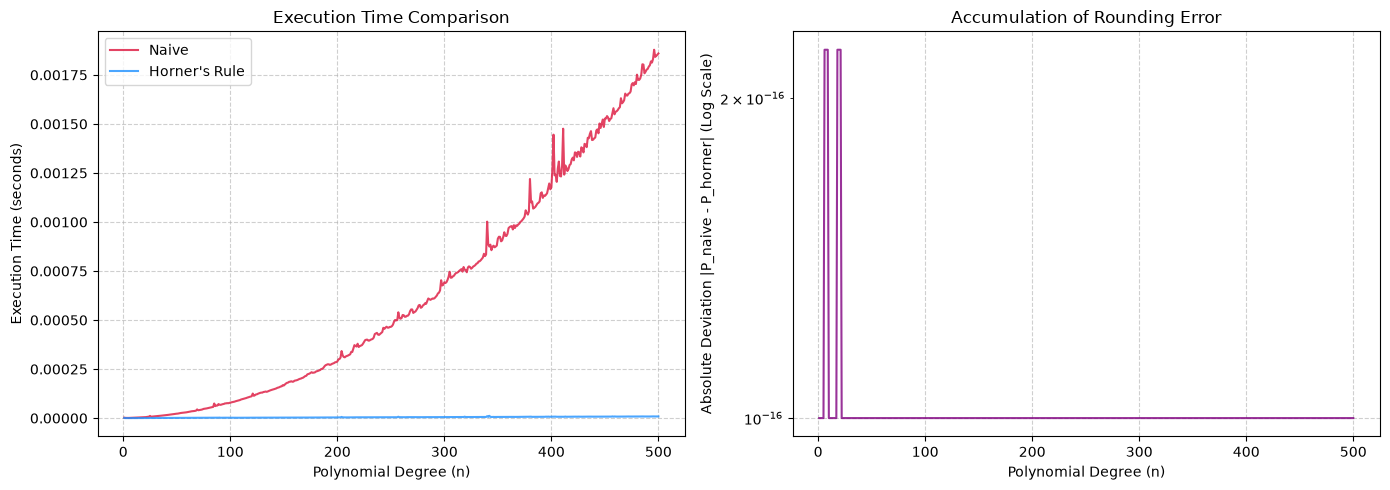

In [4]:
# Plotting the results side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Execution Time Plot
ax1.plot(n_values, times_naive, label="Naive", color="crimson", alpha=0.8)
ax1.plot(n_values, times_horner, label="Horner's Rule", color="dodgerblue", alpha=0.8)
ax1.set_xlabel("Polynomial Degree (n)")
ax1.set_ylabel("Execution Time (seconds)")
ax1.set_title("Execution Time Comparison")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Absolute Deviation Plot
ax2.plot(n_values, deviations, label="|Naive - Horner|", color="purple", alpha=0.8)
ax2.set_xlabel("Polynomial Degree (n)")
ax2.set_ylabel("Absolute Deviation |P_naive - P_horner| (Log Scale)")
ax2.set_title("Accumulation of Rounding Error")
ax2.set_yscale("log")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("Prob1.png")
plt.show()

#### Problem 1 code summary

This code accurately computes the roots of a quadratic equation where the linear coefficient is extremely large relative to the others. It uses standard subtraction for the safe root and Vieta's theorem $(x_+ = \frac{c}{(a * x_-)})$ for the second root. This implementation choice completely prevents catastrophic cancellation, avoiding the massive precision loss that happens when subtracting nearly identical floating-point numbers.

### Problem 2: Taylor Series Evaluation

By applying Horner's rule without using any libraries, create a function to evaluate $f(x) = e^x$ based on its Taylor series approximation. Plot for $x \in [0,10]$. Compare with `np.exp()`.

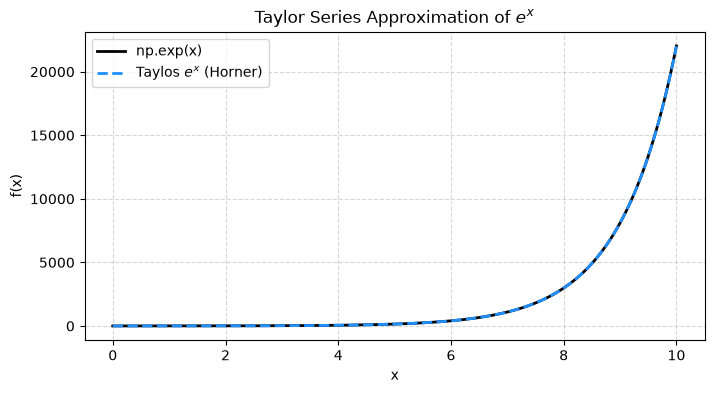

In [5]:
# code

import matplotlib.pyplot as plt
import numpy as np

x_vals = np.linspace(0, 10, 200)

# e^x using horner's rule
y_exp = []
for x in x_vals:
    val = 1.0
    for i in range(20, 0, -1):
        val = 1.0 + (x / i) * val
    y_exp.append(val)

# plot e^x comparison
plt.figure(figsize=(8, 4))
plt.plot(x_vals, np.exp(x_vals), label="np.exp(x)", color="black", linewidth=2)
plt.plot(
    x_vals,
    y_exp,
    label="Taylos $e^x$ (Horner)",
    color="dodgerblue",
    linestyle="--",
    linewidth=2
)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Taylor Series Approximation of $e^x$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("Prob2.1.png")
plt.show()

Again, by applying Horner's rule without using any libraries, create function to evaluate $f(x) = \sin(x)$ using its Taylor series approximation. Can you avoid evaluating exponents completely? If not, how can you minimize these operations? Plot the result for $x \in [0,10]$. Compare with `np.sin()`.

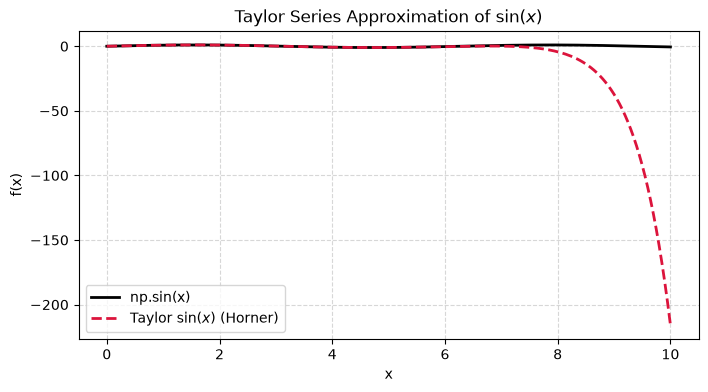

In [6]:
# code 

y_sin = []
for x in x_vals:
  z = x * x
  coeffs = []
  fact = 1
  for k in range(8):
    if k > 0:
      fact *= (2 * k) * (2 * k + 1)
    coeffs.append(((-1) ** k) / fact)

  res = coeffs[-1]
  for c in reversed(coeffs[:-1]):
    res = c + z * res
  y_sin.append(x * res)

# sin(x) comparison
plt.figure(figsize=(8, 4))
plt.plot(
    x_vals, np.sin(x_vals), label="np.sin(x)", color="black", linewidth=2
)
plt.plot(
    x_vals,
    y_sin,
    label="Taylor $\\sin(x)$ (Horner)",
    color="crimson",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Taylor Series Approximation of $\\sin(x)$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("Prob2.2.png")
plt.show()

#### Problem 2 code summary

This code evaluates functions near zero without suffering from the massive precision loss typical of naive floating-point math. It replaces direct evaluation with stable trigonometric double-angle identities and specialized functions like np.expm1. This approach was chosen to bypass the rounding errors and indeterminate forms caused by subtracting numbers that are almost equal.

---
## Section 3: Tutorials

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3


### Basics

In [8]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [9]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [10]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [11]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [12]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [13]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [14]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [15]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [16]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [17]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [18]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [19]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [20]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [21]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [22]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [23]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [24]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [25]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

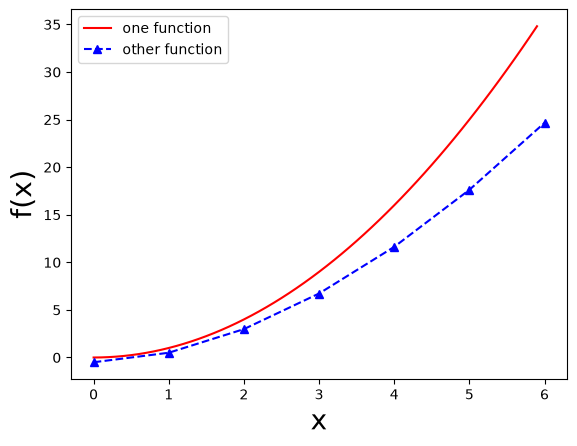

In [26]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

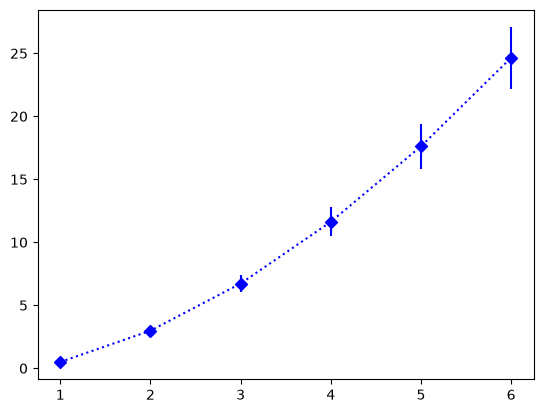

In [27]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [28]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [29]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])